In [1]:
!git clone https://github.com/Anushka-De/stat359.git
%cd stat359/student/Final_Project

Cloning into 'stat359'...
remote: Enumerating objects: 641, done.
remote: Counting objects: 100% (356/356), done.
remote: Compressing objects: 100% (205/205), done.
remote: Total 641 (delta 242), reused 218 (delta 151), pack-reused 285 (from 3)
Receiving objects: 100% (641/641), 121.08 MiB | 13.84 MiB/s, done.
Resolving deltas: 100% (334/334), done.
Updating files: 100% (240/240), done.
/content/stat359/student/Final_Project


In [12]:
import os, glob, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Accuracy Comparison

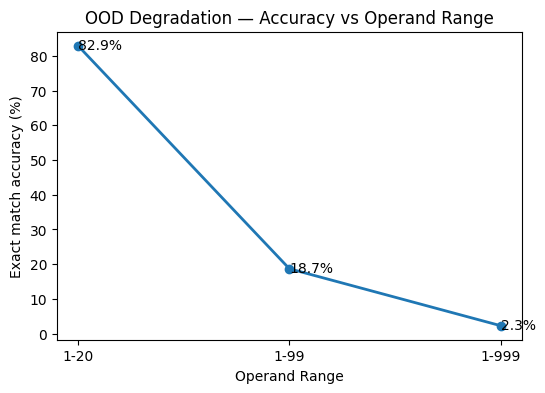

In [3]:
#Max Depth :4
depth = ["1-20","1-99","1-999"]
accuracy = [82.9, 18.70, 2.30]

plt.figure(figsize=(6,4))
plt.plot(depth, accuracy, marker="o", linewidth=2)
for x, y in zip(depth, accuracy):
    plt.text(x, y , f"{y:.1f}%", fontsize=10,  ha="left", va="center")
plt.xlabel("Operand Range")
plt.ylabel("Exact match accuracy (%)")
plt.title("OOD Degradation — Accuracy vs Operand Range")
plt.show()

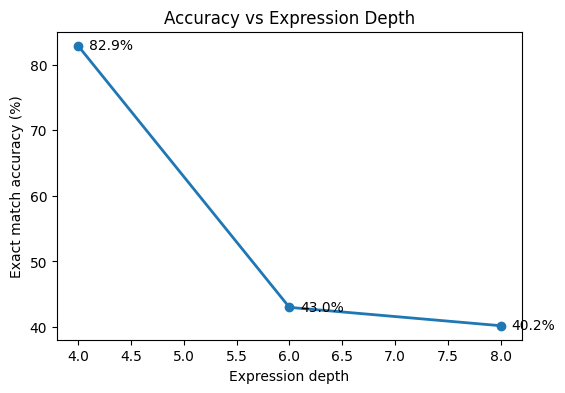

In [4]:
depth = [4,6,8]
accuracy = [82.9, 43.0, 40.2]

plt.figure(figsize=(6,4))
plt.plot(depth, accuracy, marker="o", linewidth=2)
for x, y in zip(depth, accuracy):
    plt.text(x + 0.1, y, f"{y:.1f}%", fontsize=10, va="center")
plt.xlabel("Expression depth")
plt.ylabel("Exact match accuracy (%)")
plt.title("Accuracy vs Expression Depth")
plt.show()

# Combined OOD Analysis: Range vs Depth

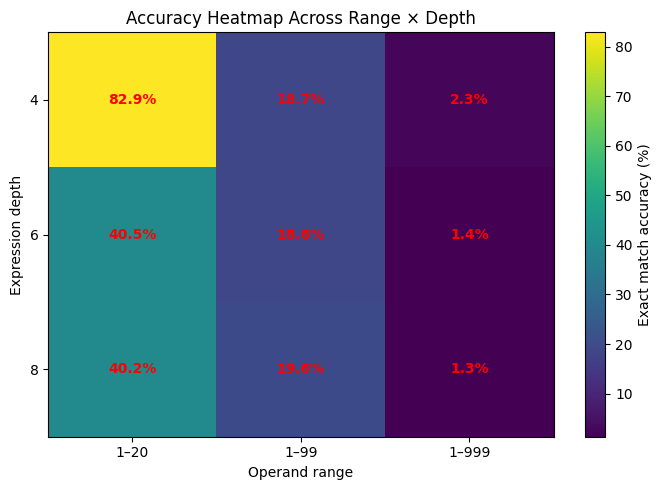

In [11]:
BASE = "arithmetic_llm/evaluation_results"

depths = [4, 6, 8]
ranges = [(1,20), (1,99), (1,999)]
range_labels = ["1–20", "1–99", "1–999"]

def latest_metrics(folder):
    files = sorted(glob.glob(os.path.join(folder, "evaluation_metrics_*.json")))
    if not files:
        return None
    with open(files[-1], "r") as f:
        return json.load(f)

# Accuracy grid (rows=depth, cols=range)
acc = np.full((len(depths), len(ranges)), np.nan)

for i, d in enumerate(depths):
    for j, (lo, hi) in enumerate(ranges):
        folder = os.path.join(BASE, f"grid_depth{d}_range{lo}_{hi}")
        m = latest_metrics(folder)
        if m is None:
            print("Missing metrics in:", folder)
            continue
        # Your metrics are already in percent units (e.g., 43.9), NOT 0-1
        acc[i, j] = m.get("exact_match_accuracy")

# Plot heatmap
plt.figure(figsize=(7,5))
im = plt.imshow(acc, aspect="auto")

plt.xticks(range(len(range_labels)), range_labels)
plt.yticks(range(len(depths)), [str(d) for d in depths])
plt.xlabel("Operand range")
plt.ylabel("Expression depth")
plt.title("Accuracy Heatmap Across Range × Depth")
plt.colorbar(im, label="Exact match accuracy (%)")

# Annotate each cell with the percent
for i in range(acc.shape[0]):
    for j in range(acc.shape[1]):
        if np.isfinite(acc[i, j]):
            plt.text(j, i, f"{acc[i,j]:.1f}%", ha="center", va="center", fontsize=10,color="red",fontweight='bold')

plt.tight_layout()
plt.show()

# Error Type Analysis

In [6]:
BASE_DIR = "arithmetic_llm/evaluation_results"
folders = {
    "1–20":  "grid_depth4_range1_20",
    "1–99":  "grid_depth4_range1_99",
    "1–999": "grid_depth4_range1_999",
}

def load_latest_samples(folder):
    files = sorted(glob.glob(os.path.join(BASE_DIR, folder, "sample_outputs_*.json")))
    if not files:
        raise FileNotFoundError(f"No sample_outputs_*.json in {folder}")
    path = files[-1]
    with open(path, "r") as f:
        samples = json.load(f)
    return samples, path

def categorize_sample(s):
    text = s.get("generated_text", "") or ""
    pred = s.get("predicted", None)
    gt   = s.get("ground_truth", None)

    # If predicted is missing, it's non-parseable
    if pred is None:
        # diagnose format error type
        has_think_open = "<think>" in text
        has_think_close = "</think>" in text
        has_final = "Final Result" in text or "Final Result:" in text or "Final Result :" in text

        if has_think_open and not has_think_close:
            return "non_parseable_unclosed_think"
        if not has_final:
            return "non_parseable_missing_final_result"
        return "non_parseable_other"

    # Parseable
    if pred == gt:
        return "correct"
    return "wrong_answer"
rows = []
for rng, folder in folders.items():
    samples, path = load_latest_samples(folder)
    for s in samples:
        rows.append({"Range": rng, "Category": categorize_sample(s)})

df = pd.DataFrame(rows)
summary = df.groupby(["Range", "Category"]).size().reset_index(name="Count")
summary["Percent"] = summary.groupby("Range")["Count"].transform(lambda x: 100*x/x.sum())
summary

,Range,Category,Count,Percent
0,1–20,correct,829,82.9
1,1–20,non_parseable_missing_final_result,3,0.3
2,1–20,non_parseable_unclosed_think,37,3.7
3,1–20,wrong_answer,131,13.1
4,1–99,correct,187,18.7
5,1–99,non_parseable_missing_final_result,1,0.1
6,1–99,non_parseable_other,2,0.2
7,1–99,non_parseable_unclosed_think,39,3.9
8,1–99,wrong_answer,771,77.1
9,1–999,correct,23,2.3


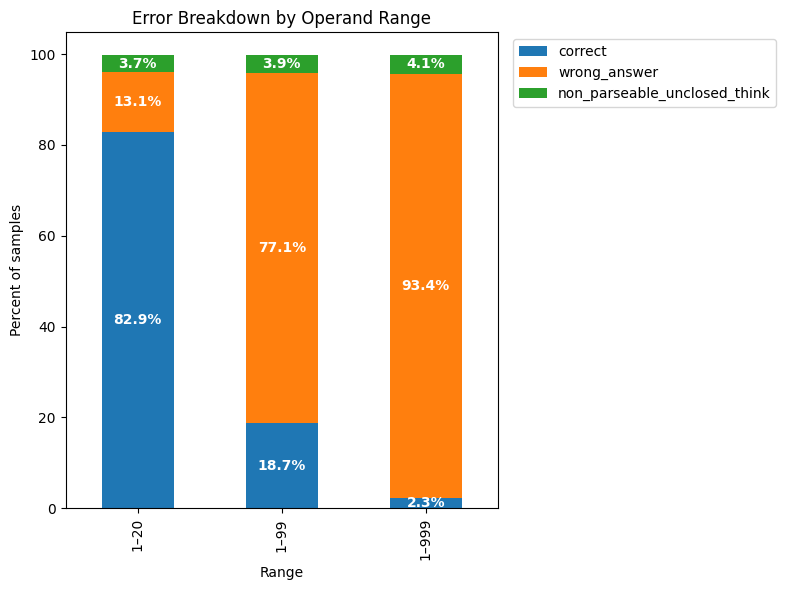

In [7]:
order = ["correct", "wrong_answer", "non_parseable_unclosed_think"]

pivot = summary.pivot(index="Range", columns="Category", values="Percent").fillna(0)
pivot = pivot[[c for c in order if c in pivot.columns]]

ax = pivot.plot(kind="bar", stacked=True, figsize=(8,6))

plt.ylabel("Percent of samples")
plt.title("Error Breakdown by Operand Range")

# Add percentage labels inside bars
for i, row in enumerate(pivot.values):
    cumulative = 0
    for j, val in enumerate(row):
        if val > 2:  # avoid clutter for very small slices
            ax.text(
                i,
                cumulative + val/2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="white",
                weight="bold"
            )
        cumulative += val

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Error Magnitude

In [13]:
BASE = "arithmetic_llm/evaluation_results"

depths = [4, 6, 8]
ranges = [(1, 20), (1, 99), (1, 999)]

def latest_samples(folder):
    files = sorted(glob.glob(os.path.join(folder, "sample_outputs_*.json")))
    if not files:
        return None
    with open(files[-1], "r") as f:
        return json.load(f)

rows = []

for d in depths:
    for lo, hi in ranges:
        folder = f"{BASE}/grid_depth{d}_range{lo}_{hi}"
        samples = latest_samples(folder)
        if samples is None:
            print("Missing samples:", folder)
            continue

        for s in samples:
            pred = s.get("predicted")
            gt = s.get("ground_truth")

            if gt is None:
                continue

            # Extract an integer from pred even if pred is messy (string etc.)
            match = re.search(r"-?\d+", str(pred))
            if not match:
                continue

            try:
                pred_int = int(match.group())
                gt_int = int(gt)
            except:
                continue

            error = abs(pred_int - gt_int)

            rows.append({
                "Range": f"{lo}-{hi}",
                "Depth": f"d={d}",
                "Error": error
            })

df_error = pd.DataFrame(rows)
df_error

,Range,Depth,Error
0,1-20,d=4,0
1,1-20,d=4,0
2,1-20,d=4,3
3,1-20,d=4,0
4,1-20,d=4,0
...,...,...,...
6722,1-999,d=8,5238
6723,1-999,d=8,810
6724,1-999,d=8,685
6725,1-999,d=8,745


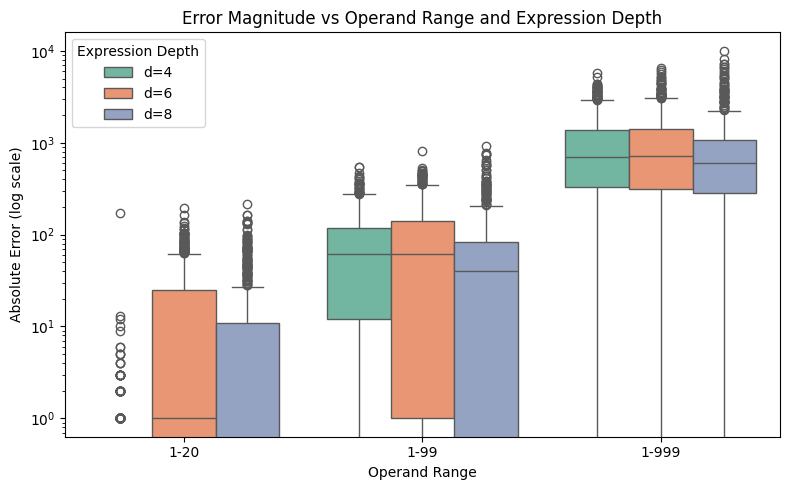

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_error,
    x="Range",
    y="Error",
    hue="Depth",
    palette="Set2"
)

plt.yscale("log")  # important because errors grow very large

plt.xlabel("Operand Range")
plt.ylabel("Absolute Error (log scale)")
plt.title("Error Magnitude vs Operand Range and Expression Depth")

plt.legend(title="Expression Depth")
plt.tight_layout()

plt.show()